In [3]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl (12.4 MB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   -------- ------------------------------- 1/5 [numpy]
   -------- ------------------------------- 1/5 [numpy]
   -------- ------------------------------- 1/5 [numpy]
   -------- ------------------------------- 1/5 [numpy]
   -------- ------------------------------- 1/

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from sklearn.datasets import make_regression
import numpy as np

In [10]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1, noise=90, random_state=13)

In [8]:
!pip install matplotlib seaborn pandas

Defaulting to user installation because normal site-packages is not writeable
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------------- ---------------------- 3.7/8.3 MB 18.8 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.3 MB 11.6 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 9.2 MB/s  0:00:00
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----------- ---------------------------- 2.9/9.9 MB 17.8 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/9.9 MB 17.6 MB/s eta 0:00:01
   -------------------------------- ------- 8.1/9.9 MB 14.2 MB/s eta 0:00:01
   ----------------------------------- ---- 8.7/9.9 MB 11.3 MB/s eta 0:00:01
   ---------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


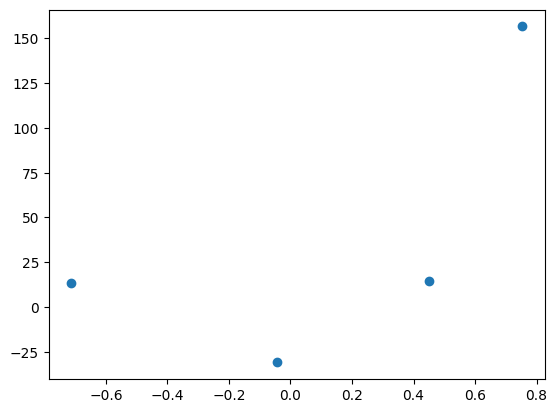

In [11]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [12]:
#Lets apply OLS
from sklearn.linear_model import LinearRegression

In [13]:
reg = LinearRegression()
reg.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
reg.coef_

array([80.53143548])

In [15]:
reg.intercept_

np.float64(29.429586948524197)

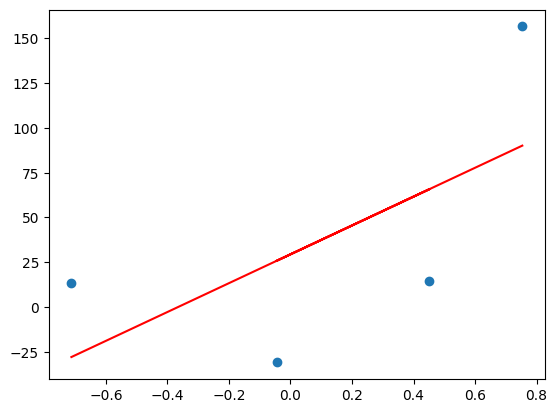

In [16]:
plt.scatter(X,y)
plt.plot(X, reg.predict(X), color = 'red')

In [18]:
# Making GD assuming slope is m = 80.53
# Start with b = 0
y_pred = ((80.53 * X) + 0).reshape(4)

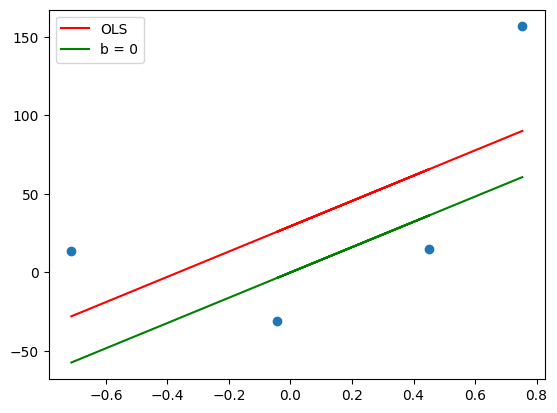

In [20]:
plt.scatter(X, y)
plt.plot(X, reg.predict(X), color = 'red', label = 'OLS')
plt.plot(X, y_pred, color = 'green', label = 'b = 0')
plt.legend()
plt.show()

In [21]:
m = 80.53
b = 0

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-235.43798374471953)

In [22]:
# Assume Learning rate is 0.1
lr = 0.1

step_size = loss_slope*lr
step_size

np.float64(-23.543798374471955)

In [23]:
# Calculate a new new intercept
b = b - step_size
b

np.float64(23.543798374471955)

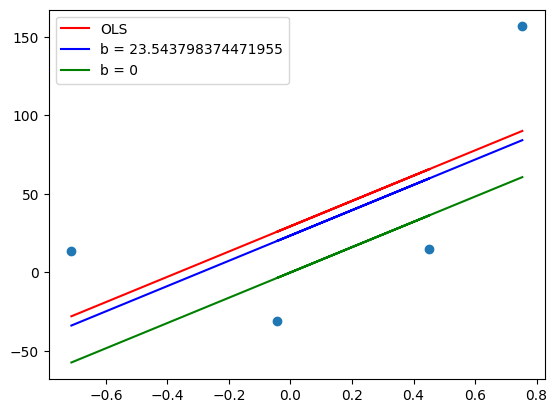

In [25]:
y_pred1 = ((80.53 * X) + b).reshape(4)

plt.scatter(X, y)
plt.plot(X, reg.predict(X), color = 'red', label = 'OLS')
plt.plot(X, y_pred1, color = 'blue', label = 'b = {}'.format(b))
plt.plot(X, y_pred, color = 'green', label = 'b = 0')
plt.legend()
plt.show()

In [26]:
# Epoch = 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-47.08759674894391)

In [27]:
step_size = loss_slope*lr
step_size

np.float64(-4.708759674894391)

In [28]:
# Calculate a new new intercept
b = b - step_size
b

np.float64(28.252558049366346)

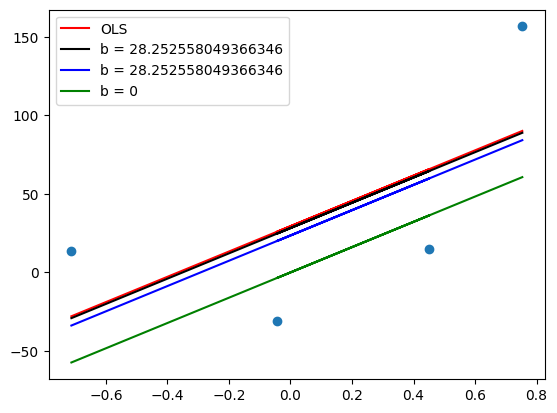

In [29]:
y_pred2 = ((80.53 * X) + b).reshape(4)

plt.scatter(X, y)
plt.plot(X, reg.predict(X), color = 'red', label = 'OLS')
plt.plot(X, y_pred2, color = 'black', label = 'b = {}'.format(b))
plt.plot(X, y_pred1, color = 'blue', label = 'b = {}'.format(b))
plt.plot(X, y_pred, color = 'green', label = 'b = 0')
plt.legend()
plt.show()

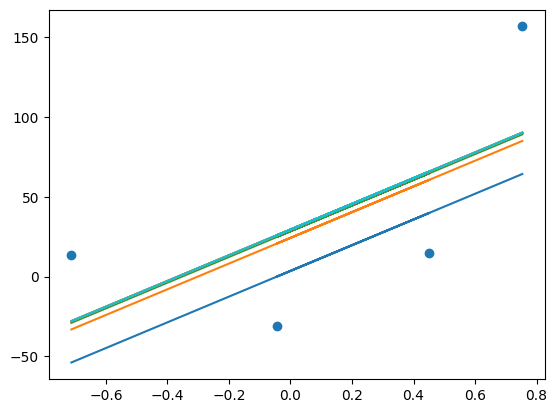

In [30]:
# Making a Loop of it

b = -100
m = 80.53
lr = 0.1

epochs = 10

for i in range(epochs):
    loss_slope = -2 * np.sum(y - m*X.ravel() - b)
    b = b - (lr * loss_slope)
    y_pred = m * X + b
    plt.plot(X, y_pred)

plt.scatter(X, y)


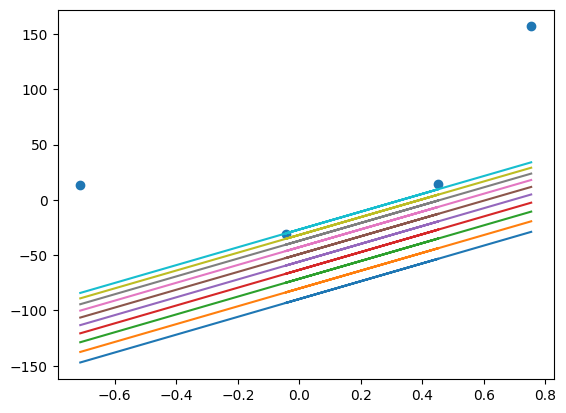

In [31]:
# Making a Loop of it with less learning rate

b = -100
m = 80.53
lr = 0.01

epochs = 10

for i in range(epochs):
    loss_slope = -2 * np.sum(y - m*X.ravel() - b)
    b = b - (lr * loss_slope)
    y_pred = m * X + b
    plt.plot(X, y_pred)

plt.scatter(X, y)
